In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation 

In [2]:
# Defining dataset
Positive_Points = np.array([(-2,3),(0,1),(2,-1)])
Negative_Points = np.array([(-2,1),(0,-1),(2,-3)])

In [3]:
Positive_Points

array([[-2,  3],
       [ 0,  1],
       [ 2, -1]])

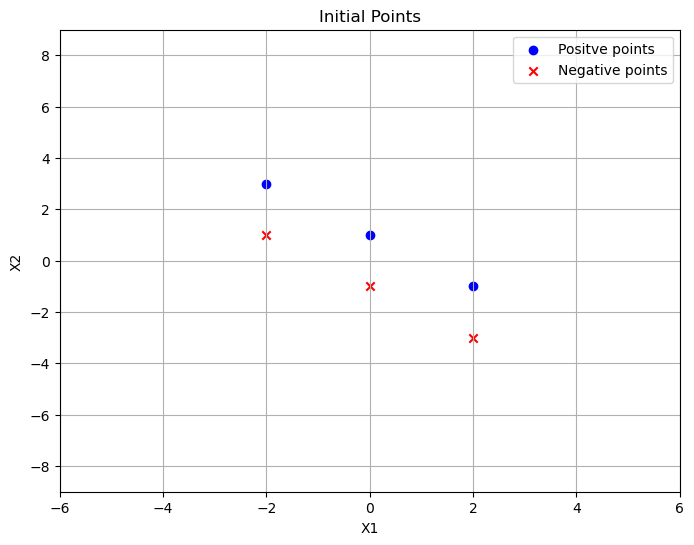

In [4]:
# Plot intitial points
plt.figure(figsize=(8,6), dpi=100)
plt.scatter(Positive_Points[:,0],Positive_Points[:,1],c='blue',label = 'Positve points')
plt.scatter(Negative_Points[:,0],Negative_Points[:,1],marker='x',c='red',label = 'Negative points')
plt.xlabel('X1')
plt.ylabel('X2')
plt.grid(True)
plt.margins(True)
plt.title('Initial Points')
plt.legend(loc = 'best')
plt.show()

In [5]:
X = np.vstack((Positive_Points,Negative_Points))
Y = np.hstack(([1]*len(Positive_Points),[-1]*len(Negative_Points)))

1. The Perceptron algorithm works by correcting one mistake at a time.
2. After updating the weights (theta) and bias (theta0) based on the first misclassified point:

    0. The decision boundary has changed.
    0. Continuing to update using the same step would be meaningless because the boundary is now different.

3. break ensures that the algorithm re-evaluates the data with the new boundary before continuing.

In [6]:
def plot_decision_boundary(theta, theta0, iteration):
    plt.scatter(Positive_Points[:, 0], Positive_Points[:, 1], c='blue', label='Positive Point')
    plt.scatter(Negative_Points[:, 0], Negative_Points[:, 1], c='red', label='Negative Point')

    # Plot decision boundary
    x_val = np.linspace(-3, 3, 10)
    if theta[1] != 0:
        y_val = -(theta[0] * x_val + theta0) / theta[1]
        plt.plot(x_val, y_val, linestyle='--', label=f'Iteration {iteration}')
    else:
        x_val = -theta0 / theta[0]
        plt.axvline(x=x_val, linestyle="--", label=f'Iteration {iteration}')

    plt.xlim(-3, 3)
    plt.ylim(-4, 4)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(f"Decision boundary at iteration {iteration}")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

In [7]:
print(np.linspace(-3,3,2))

[-3.  3.]


In [8]:
# Defining Perceptron
def Percepron(X,Y,steps):
    theta = np.zeros(X.shape[1])# here 1 epresent no of columns and 0 represent no of rows
    theta0 = 0
    for t in range(steps):
        for i,xi in enumerate(X):
            if Y[i]*(np.dot(xi,theta) + theta0) <= 0:
                theta += Y[i]*xi
                theta0 += Y[i]
                break
        #plot decisioon boundary
        plot_decision_boundary(theta,theta0,t+1)
    return theta,theta0

                

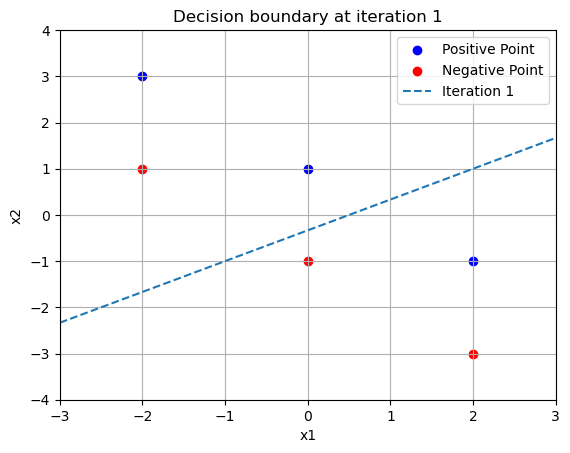

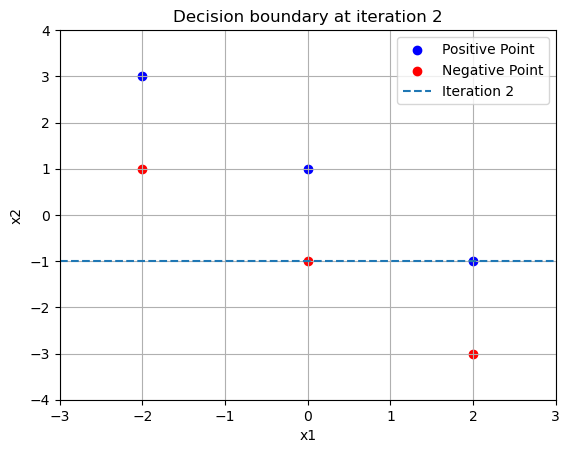

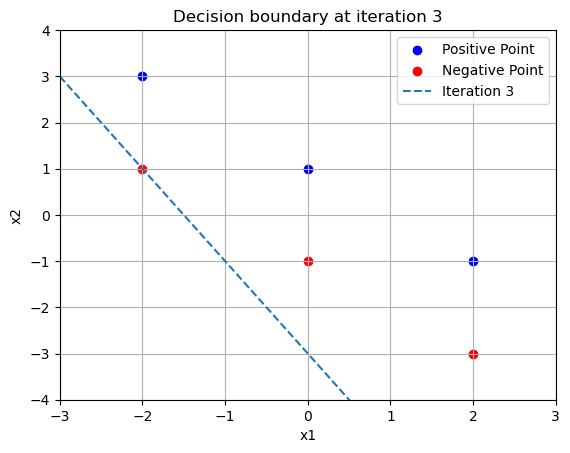

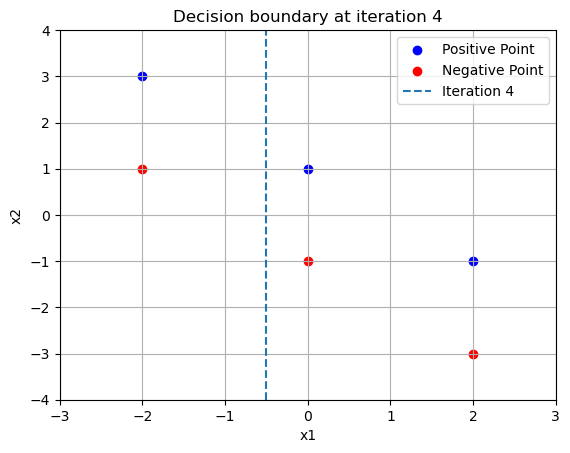

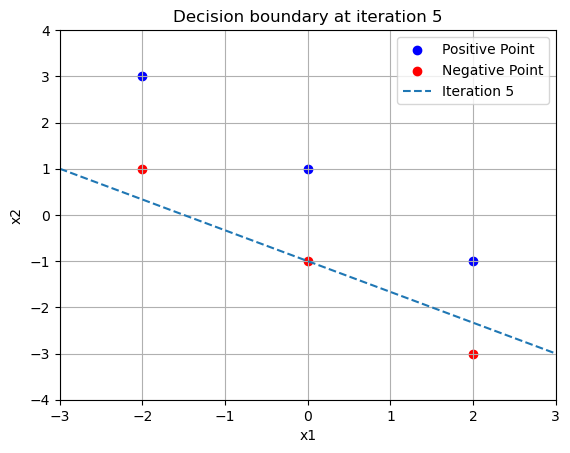

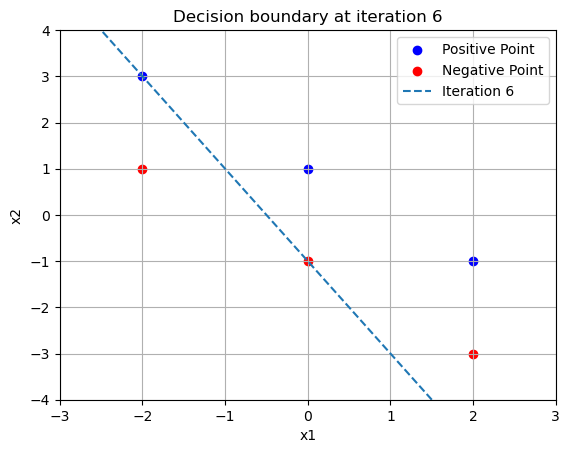

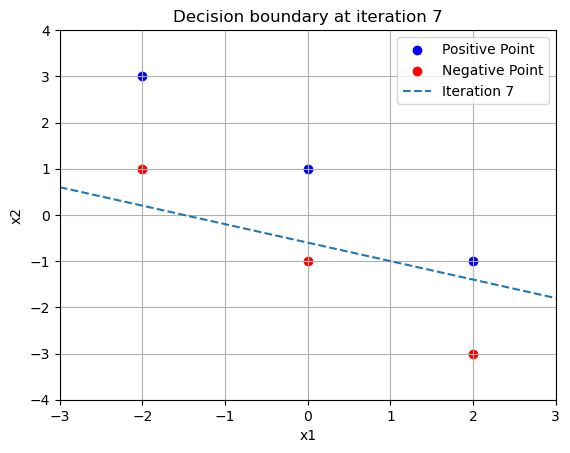

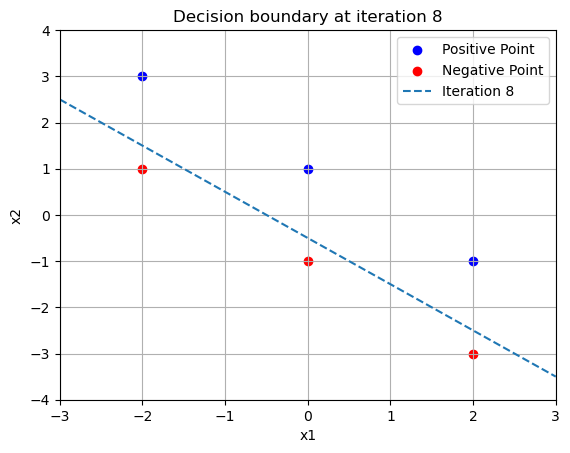

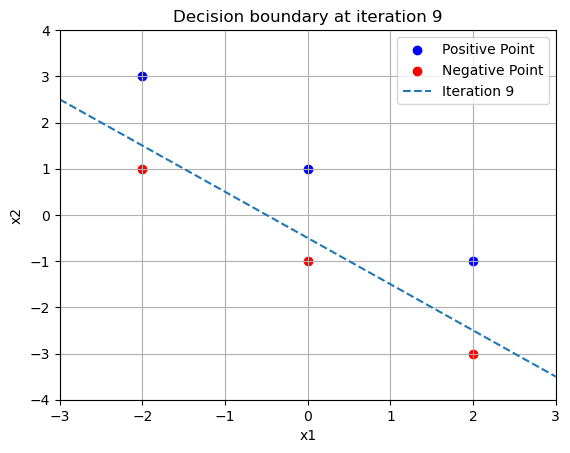

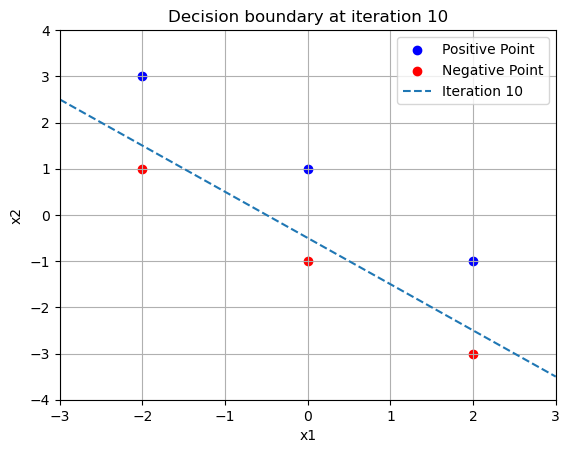

In [9]:
theta_final,theta0_final = Percepron(X,Y,10)